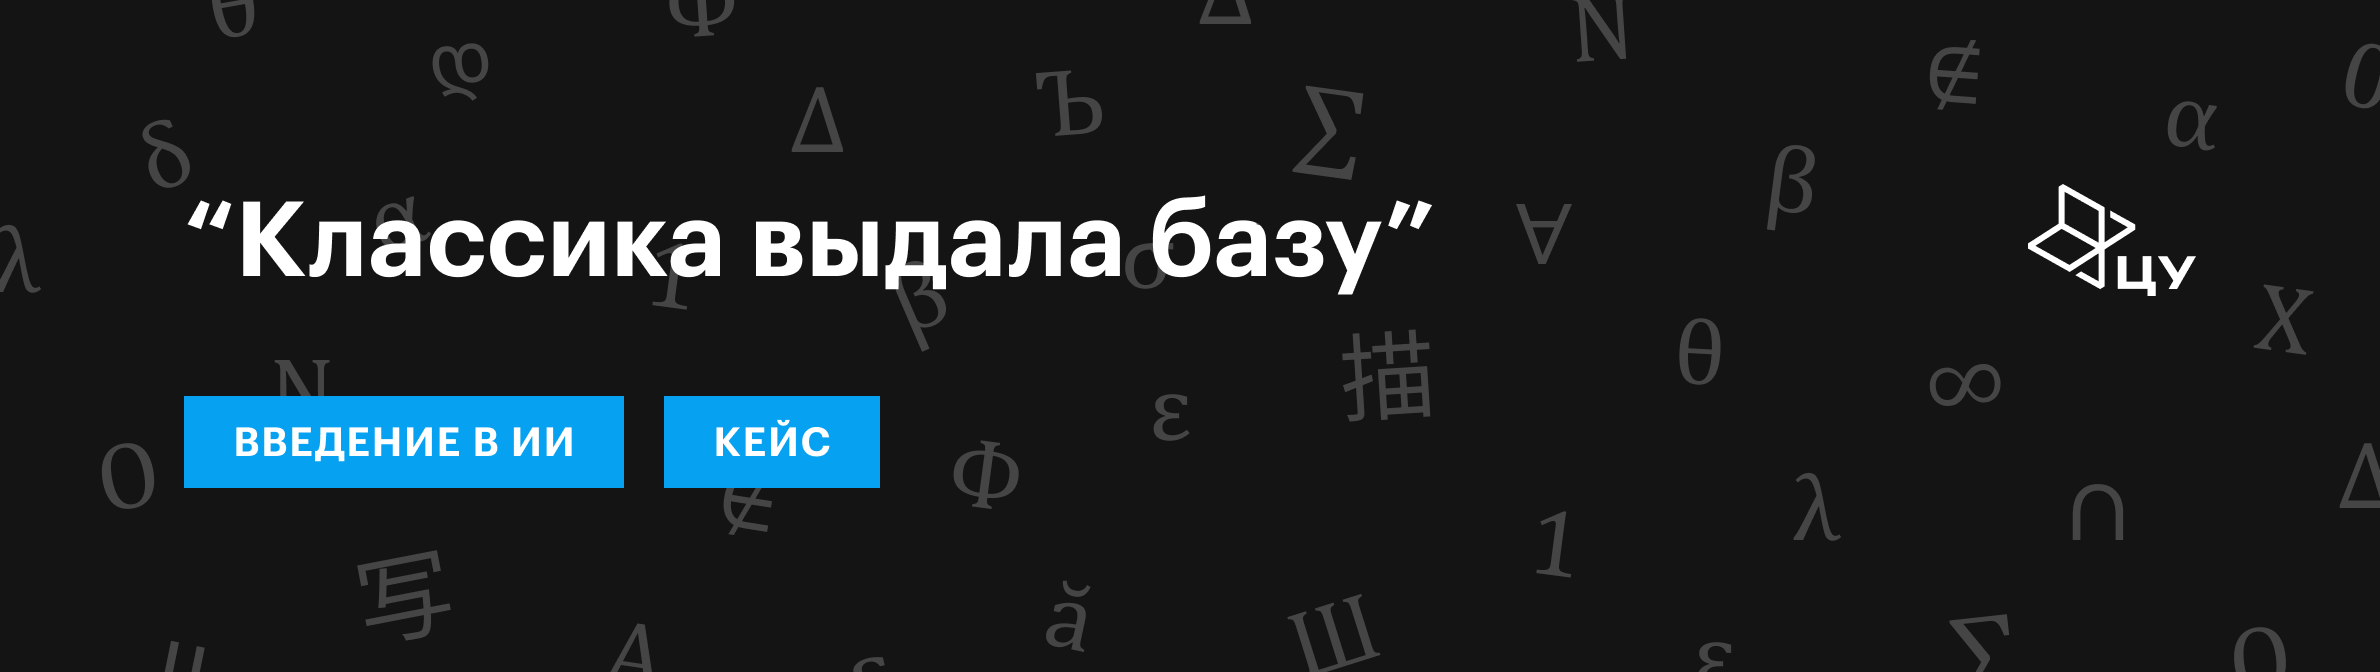

## Легенда

Представьте, что вы устроились NLP-инженером в образовательный EdTech-стартап. Маркетологи компании выяснили, что современные школьники тяжело воспринимают язык классической литературы XIX века.(Также в компанию наняли инженера, который смог встроить в каждую электронную книжкуу по экрану с Subway Surfers, чтобы ученикам было привычнее) Обилие устаревших слов, французских вставок и сложных деепричастных оборотов заставляет их «скипать» чтение.

Стартап решил запустить революционное приложение, которое будет «на лету» переводить тексты Толстого, Достоевского и Гоголя на современный интернет-сленг*.

Ваша задача: разработать нейросетевую Seq2Seq-модель, которая осуществляет перенос стиля (Text Style Transfer). Модель должна брать оригинальную реплику из классики и переписывать ее зумерским сленгом, максимально сохраняя смысл и изначальную структуру предложения.

*Примечение от автора кейса: данные по сленгу собирались из открытых источников: статей в интернете, рилсам, шортсам и тикитокам.*

## Требования к решению

Поскольку это учебный проект, вводятся следующие технические ограничения:

* **Запрет на API-читерство:** Запрещено просто прогнать тестовый датасет через API умных ЛЛМок. Вы должны самостоятельно обучить модель. *При этом, если вам хочется использовать API LLM-сервисов для обогащения датасета, аугментаций и уточнения перевода, то это не запрещено.*

* **Ограничение по размеру модели:** Решение должно корректно работать в Google Colab. Использовать несколько Google-аккаунтов для увеличения квоты на Т4 для экспериментов с архитектурой не запрещено

* **Воспроизводимость:** Весь код должен выполняться последовательно с первого раза. Обязательно фиксируйте random_seed, а также сохраняйте веса моделей и логируйте эксперимент.

**Необходимые этапы решения:**

1. Работа с датасетом. Посмотреть на статистику встречаемости слов и провести предобработку. Определиться с токенизатором и предложить простой бейзлайн.


2. Подбор архитектуры модели. Написание необходимых функций для работы с данной архитектурой. (Например, обрезка текста до 128 символов, для моделей с маленьким контекстным окном)


3. Обучение модели на датасете. Валидация метрик, подбор гиперпарметров генерации. Вспомогательные функции для генерации перевода для новых предложений (тут можно сделать функцию `def translate(text)`, которая занимается переводом текста)

**Проверяемые метрики:**

Оценка качества генерации текста — сложная задача. Мы будем использовать две метрики и смотреть на Loss модели:

*  Обучение (Train/Val Loss): Cross-Entropy Loss. Функция потерь, по которой модель обновляет веса. Желательно избежать переобучения и достичь результатов по Loss меньше ~1.5-2.0

* Главная бизнес-метрика: chrF (Character n-gram F-score). Оценивает совпадение сгенерированного текста с эталоном на уровне символов. Она идеально подходит для сленга, так как прощает ошибки в окончаниях (например, если модель выдала «кринж» вместо «кринжово»).

*  Вспомогательная метрика: BLEU-score. Классическая метрика машинного перевода. Посчитайте её для сравнения с chrF. Данная метрика легко считается и является бейзлайн-метрикой для любой задачи перевода.





## Система оценивания

Решение оценивается по трём параметрам
* **Работа с данными [4 балла]:** Оценка ставится в соответствии с тем, насколько подробно была произведена работа с данными — визуализации, предобработка и очистка/обогащение датасета будут плюсом

* **Решение задачи [4 балла]:** Оценка ставится не за итоговые метрики — для простых моделей их значение может быть небольшим, а за то, насколько качественно были проделаны эксперименты в рамках выбранной модели. То есть если в решении используется примитивная модель, получающая низкие метрики, но она обучена с разными гиперпараметрами и приёмами так, что из её качества выжимается максимум, это решение будет оценено в полный балл

* **Оформление [2 балла]:** Хочется, чтобы написанный код читался, как хорошая книга. Для этого мы добавляем баллы за оформление — они выше, если в коде появляются визуализации, комментарии к коду и сопроводительный текст, и ниже за их отсутствие

## Данные

Итоговый датасет содержит 2 колонки: chunk и translate. В столбце chunk находится кусочек текста из классики. А в столбце translate – соответствующий ему перевод.


В данном датасете вы можете найти отрывки из следующих книг / сборников / произведений:

* А. П. Чехов — Собрание сочинений (рассказы и пьесы)

* А. С. Пушкин — повесть «Пиковая дама»

* И. С. Тургенев — роман «Отцы и дети»

* М. Ю. Лермонтов — роман «Герой нашего времени»

* Н. В. Гоголь — комедия «Ревизор»

* Н. В. Гоголь — поэма «Мёртвые души»

* А. Н. Островский — Собрание пьес (включая драму «Гроза»)

* Л. Н. Толстой — роман-эпопея «Война и мир»

* Ф. М. Достоевский — роман «Братья Карамазовы»



Для подбора метода, желательно подробно исследовать датасет – можно начать с простого просмотра перевода, а закончить построение векторных представлений слов. *Главное помните, EDA должен привести вас к пониманию решения проблемы*

Ссылка на датасет: https://drive.google.com/file/d/1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7/view

## Пояснение метрик



**BLEU-score** (Bilingual Evaluation Understudy)
Метрика основана на совпадении целых слов (униграмм) и их комбинаций (n-грамм: биграмм, триграмм и т.д.). Итоговый BLEU считается как геометрическое среднее точностей n-грамм, умноженное на штраф за краткость.

Формула:
$BLEU = BP \cdot \exp\left( \sum_{n=1}^{N} w_n \log p_n \right)$

Где:

$p_n$ — точность совпадения n-грамм (доля n-грамм из генерации, которые нашлись в эталоне).

$w_n$ — вес для $n$-граммы (обычно берут равномерные веса, например, для BLEU-4: $w_n = 0.25$).

$N$ — максимальная длина n-граммы (стандарт — 4).

$BP$ (Brevity Penalty) — штраф за краткость. Запрещает модели читерить, выдавая по одному правильному слову.

Формула штрафа за краткость ($BP$):
BP = \begin{cases} 1, & \text{если } c > r \\ \exp\left(1 - \frac{r}{c}\right), & \text{если } c \le r \end{cases}
Где $c$ — длина сгенерированного текста (candidate), $r$ — длина эталона (reference).



**chrF** (Character n-gram F-score)
В отличие от BLEU, chrF разбивает текст не на слова, а на символьные подстроки (от 1 до 6 символов) и считает по ним классическую F-меру.

Сначала считаются Precision и Recall для совпавших символьных кусочков:

$Precision (P) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в генерации}}$


$Recall (R) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в эталоне}}$

Затем вычисляется итоговая формула chrF (это стандартная $F_\beta$-мера):

$chrF = (1 + \beta^2) \frac{P \cdot R}{\beta^2 \cdot P + R}$

Где:

$\beta$ — параметр, определяющий баланс между точностью и полнотой.

В стандартной реализации (chrF2) используют $\beta = 2$, что дает больший вес Recall (полноте) — то есть алгоритму важнее, чтобы модель не потеряла смысл оригинала, даже если она добавила от себя лишние символы.

### Пример работы метрик

**Оригинал:** "Это было ужасно"

**Эталон**: "это было кринжово"

**Сгенерировано моделью:** "это был кринж"

----



BLEU разбивает текст по пробелам:

Слова эталона: ["это", "было", "кринжово"]

Слова модели: ["это", "был", "кринж"]

Для BLEU слова "было" и "был", а также "кринжово" и "кринж" — это абсолютно разные, никак не связанные слова (как "собака" и "самолет"). Совпало только одно слово: "это".


Шаг 1: Считаем совпадения (Precision для n-грамм)

1-граммы (отдельные слова): Из 3 сгенерированных слов в эталоне есть только одно — "это". $p_1 = 1 / 3 \approx 0.33$ (33%).

2-граммы (пары слов):
Пары модели: ["это был", "был кринж"].
Пары эталона: ["это было", "было кринжово"].
Совпадений нет! Точность $p_2 = 0 / 2 = 0$.

Шаг 2: Штраф за краткость (Brevity Penalty)
Длина генерации ($c=3$) равна длине эталона ($r=3$), поэтому модель не штрафуется за обрывание текста. $BP = 1$

Шаг 3: Итоговая формула BLEU

$$BLEU = BP \cdot \exp\left( \frac{1}{2} \log p_1 + \frac{1}{2} \log p_2 \right)$$

Так как точность биграмм $p_2 = 0$, логарифм нуля уходит в минус бесконечность, и весь BLEU обнуляется.

$$BLEU = 0$$

- - -

chrF нарезает текст на куски (например, по 4 символа, включая пробелы):

Куски эталона (14 штук):
"это_", "то_б", "о_бы", "_был", "было", "ыло_", "ло_к", "о_кр", "_кри", "крин", "ринж", "инжо", "нжов", "жово"

Куски модели (10 штук):
"это_", "то_б", "о_бы", "_был", "был_", "ыл_к", "л_кр", "_кри", "крин", "ринж"

Шаг 1: Ищем совпадения
Алгоритм сравнивает два списка и находит 7 идеальных совпадений:
"это_", "то_б", "о_бы", "_был", "_кри", "крин", "ринж". Корень слова и начало предложения схвачены верно!

Алгоритм видит, что куски "это ", "то б", " был", " кри", "крин", "ринж" совпали


Шаг 2: Считаем Точность (Precision) и Полноту (Recall)

Precision ($P$): Доля правильных кусков среди всех сгенерированных.
$P = 7 / 10 = 0.70$ (70% того, что выдала модель — верно).

Recall ($R$): Доля кусков эталона, которые смогла покрыть модель.
$R = 7 / 14 = 0.50$ (Модель восстановила 50% от оригинальной строки).

Шаг 3: Итоговая формула (F2-score)
chrF по умолчанию использует $\beta = 2$, что дает Полноте в 2 раза больший вес, чем Точности (важнее не потерять смысл, чем не наделать опечаток).

$$chrF = 5 \frac{P \cdot R}{4p+R}$$

Подставляем наши числа и получаем ответ:

$$chrF = 5 \frac{0.7 \cdot 0.5}{4\cdot 0.7 + 0.5} \approx 0.53$$

### Код метрик

Ниже уже реализованы функции подсчёта метрик. Тебе необходимо лишь использовать их

In [ ]:
import math
from collections import Counter

def get_word_ngrams(tokens: list, n: int) -> list:
    """
    Разбивает список токенов на n-граммы уровня слов.
    """
    return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


def get_char_ngrams(text: str, n: int) -> list:
    """
    Разбивает строку на n-граммы уровня символов.
    """
    return [text[i : i + n] for i in range(len(text) - n + 1)]


Покажем как работает базовое разбиение на n-граммы: посимвольные и по-"подсловные".

In [ ]:
get_word_ngrams(["я", "тебя", "крашу", "чееел"], 2)

[('я', 'тебя'), ('тебя', 'крашу'), ('крашу', 'чееел')]

In [ ]:
get_char_ngrams("кринж", 3)

['кри', 'рин', 'инж']

Вычислим теперь наши метрики для двух наших текстов

In [ ]:
def bleu_single(reference: str, candidate: str, max_n: int = 4) -> float:
    """
    Вычисляет BLEU-score для одной пары (reference, candidate).
    Шаги:
      1. Токенизация — разбиение по пробелам
      2. Clipped precision — для каждого n считаем долю n-грамм генерации,
         которые есть в эталоне; одна n-грамма эталона не засчитывается дважды
      3. Add-1 сглаживание — (matches + 1) / (total + 1), чтобы избежать log(0)
         при нулевых совпадениях в высших n-граммах
      4. Brevity Penalty — штраф exp(1 - r/c), если генерация короче эталона

    Args:
        reference : эталонный текст (строка)
        candidate : сгенерированный текст (строка)
        max_n     : максимальный порядок n-граммы (по умолчанию 4 → BLEU-4)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    ref_tokens  = reference.lower().split()
    cand_tokens = candidate.lower().split()

    c = len(cand_tokens)
    r = len(ref_tokens)

    if c == 0:
        return 0.0

    # Штрафуем только за генерацию короче эталона; длиннее — штрафа нет
    bp  = 1.0 if c > r else math.exp(1 - r / c)
    w_n = 1.0 / max_n
    log_avg = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_word_ngrams(ref_tokens, n))
        cand_ngrams = Counter(get_word_ngrams(cand_tokens, n))

        # Clipped: не даём модели накручивать счёт повторами одной n-граммы
        matches = sum(min(cnt, ref_ngrams[ngram]) for ngram, cnt in cand_ngrams.items())
        total   = max(c - n + 1, 1)  # floor=1, если предложение короче n

        # Нет совпадений даже на уровне слов — тексты семантически разные
        if n == 1 and matches == 0:
            return 0.0

        p_n      = (matches + 1) / (total + 1)
        log_avg += w_n * math.log(p_n)

    return bp * math.exp(log_avg)


def chrf_single(reference: str, candidate: str, max_n: int = 6, beta: float = 2.0) -> float:
    """
    Вычисляет chrF-score для одной пары (reference, candidate).

    Шаги:
      1. Разбить оба текста на символьные n-граммы (для n от 1 до max_n)
      2. Для каждого n посчитать Precision и Recall по совпавшим кускам
      3. Усреднить Precision и Recall по всем n
      4. Итог: F_beta-мера из усредненных P и R

    Args:
        reference  : эталонный текст (строка)
        candidate  : сгенерированный текст (строка)
        max_n      : максимальный порядок символьной n-граммы (по умолчанию 6)
        beta       : вес Recall относительно Precision (по умолчанию 2.0 -> chrF2)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    if len(candidate) == 0 or len(reference) == 0:
        return 0.0

    total_precision = 0.0
    total_recall    = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_char_ngrams(reference, n))
        cand_ngrams = Counter(get_char_ngrams(candidate, n))

        # Считаем совпавшие символьные куски
        matches = sum(
            min(count, ref_ngrams.get(ngram, 0))
            for ngram, count in cand_ngrams.items()
        )

        total_cand = sum(cand_ngrams.values())  # знаменатель Precision
        total_ref  = sum(ref_ngrams.values())   # знаменатель Recall

        if total_cand > 0:
            total_precision += (matches + 1)/ (total_cand + 1)
        if total_ref > 0:
            total_recall += matches / total_ref

    # Усредняем Precision и Recall по всем порядкам n
    avg_p = total_precision / max_n
    avg_r = total_recall    / max_n

    if avg_p + avg_r == 0:
        return 0.0

    # считаем f-бета меру
    chrf = (1 + beta**2) * (avg_p * avg_r) / (beta**2 * avg_p + avg_r)
    return chrf




А теперь с помощью функций выше напишем вычисление метрик для массива текстов. Мы используем такой же интерфейс как у `sci-kit-learn`, где есть необходимо передать `y_true` и `y_pred`

In [ ]:
def compute_bleu(y_true: list, y_pred: list, max_n: int = 4) -> float:
    """Считает средний BLEU по всем парам датасета."""
    scores = [bleu_single(ref, cand, max_n) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


def compute_chrf(y_true: list, y_pred: list, max_n: int = 6, beta: float = 2.0) -> float:
    """Считает средний chrF по всем парам датасета."""
    scores = [chrf_single(ref, cand, max_n, beta) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


А здесь мы посмотрим на примеры работы этих метрик с помощью assert-ов

In [ ]:

# ──────────────── ТЕСТ 1 ────────────────
# Идеальное совпадение: предсказание == эталон
# Ожидание: BLEU = 1.0, chrF = 1.0
ref = "этот анк выдал жесткую базу"
assert bleu_single(ref, ref) == 1.0, \
    "ТЕСТ 1 BLEU: При идеальном совпадении BLEU должен быть 1.0"
assert abs(chrf_single(ref, ref) - 1.0) < 1e-9, \
    " ТЕСТ 1 chrF: При идеальном совпадении chrF должен быть 1.0"
print("Тест 1 пройден: Идеальное совпадение → BLEU=1.0, chrF=1.0")

# ──────────────── ТЕСТ 2 ────────────────
# Пустая генерация: candidate = ""
# Ожидание: BLEU = 0.0, chrF = 0.0
ref = "он буквально вкрашился в неё"
assert bleu_single(ref, "") == 0.0, \
    " ТЕСТ 2 BLEU: Пустая генерация должна давать 0.0"
assert chrf_single(ref, "") == 0.0, \
    " ТЕСТ 2 chrF: Пустая генерация должна давать 0.0"
print("Тест 2 пройден: Пустая генерация → BLEU=0.0, chrF=0.0")

# ──────────────── ТЕСТ 3 ────────────────
# Полностью разные тексты
# Ожидание: BLEU = 0.0, chrF близко к 0
ref  = "служить бы рад прислуживаться тошно"
cand = "икс игрек зет фу бар"
assert bleu_single(ref, cand) == 0.0, \
    " ТЕСТ 3 BLEU: Полностью разные тексты → BLEU должен быть 0.0"
assert chrf_single(ref, cand) < 0.1, \
    " ТЕСТ 3 chrF: Полностью разные тексты → chrF должен быть близок к 0"
print(" Тест 3 пройден: Полностью разные тексты → BLEU=0.0, chrF≈0")

# ──────────────── ТЕСТ 4 ────────────────
# Ключевой тест: chrF > BLEU при морфологическом совпадении
# "кринж" vs "кринжово" — разные слова для BLEU, но похожие символьно для chrF
ref  = "это было кринжово"
cand = "это было кринж"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert chrf_score > bleu_score, \
    f" ТЕСТ 4: chrF ({chrf_score:.3f}) должен быть > BLEU ({bleu_score:.3f}) при морфологических различиях!"
print(f" Тест 4 пройден: chrF ({chrf_score:.3f}) > BLEU ({bleu_score:.3f}) — chrF лучше для русской морфологии!")

# ──────────────── ТЕСТ 5 ────────────────
# Частичное совпадение: значения должны быть строго в диапазоне (0, 1)
ref  = "базаров выдал жесткую базу и ливнул"
cand = "базаров выдал базу и просто ушел"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert 0.0 < bleu_score < 1.0, \
    f" ТЕСТ 5 BLEU: При частичном совпадении BLEU должен быть в (0, 1), получили {bleu_score:.3f}"
assert 0.0 < chrf_score < 1.0, \
    f" ТЕСТ 5 chrF: При частичном совпадении chrF должен быть в (0, 1), получили {chrf_score:.3f}"
print(f" Тест 5 пройден: Частичное совпадение → BLEU={bleu_score:.3f}, chrF={chrf_score:.3f}")

# ──────────────── ТЕСТ 6 ────────────────
# Тест усреднения по датасету
y_true = ["этот скуф выдал базу",     "она ливнула с вписки"]
y_pred = ["этот скуф выдал базу",     "она ливнула с вписки"]  # идеальные предсказания
assert compute_bleu(y_true, y_pred) == 1.0, \
    " ТЕСТ 6 BLEU: Усредненный BLEU по идеальным парам должен быть 1.0"
assert abs(compute_chrf(y_true, y_pred) - 1.0) < 1e-9, \
    " ТЕСТ 6 chrF: Усредненный chrF по идеальным парам должен быть 1.0"
print(" Тест 6 пройден: Усреднение по датасету работает корректно!")


Тест 1 пройден: Идеальное совпадение → BLEU=1.0, chrF=1.0
Тест 2 пройден: Пустая генерация → BLEU=0.0, chrF=0.0
 Тест 3 пройден: Полностью разные тексты → BLEU=0.0, chrF≈0
 Тест 4 пройден: chrF (0.825) > BLEU (0.595) — chrF лучше для русской морфологии!
 Тест 5 пройден: Частичное совпадение → BLEU=0.366, chrF=0.560
 Тест 6 пройден: Усреднение по датасету работает корректно!


## Пример работы метрик

**Оригинал:** "Это было ужасно".

**Эталон**: "это было кринжово"

**Сгенерировано моделью:** "это был кринж"




----



BLEU разбивает текст по пробелам:

Слова эталона: ["это", "было", "кринжово"]

Слова модели: ["это", "был", "кринж"]

Для BLEU слова "было" и "был", а также "кринжово" и "кринж" — это абсолютно разные, никак не связанные слова (как "собака" и "самолет"). Совпало только одно слово: "это".


Шаг 1: Считаем совпадения (Precision для n-грамм)

1-граммы (отдельные слова): Из 3 сгенерированных слов в эталоне есть только одно — "это". $p_1 = 1 / 3 \approx 0.33$ (33%).

2-граммы (пары слов):
Пары модели: ["это был", "был кринж"].
Пары эталона: ["это было", "было кринжово"].
Совпадений нет! Точность $p_2 = 0 / 2 = 0$.

Шаг 2: Штраф за краткость (Brevity Penalty)
Длина генерации ($c=3$) равна длине эталона ($r=3$), поэтому модель не штрафуется за обрывание текста. $BP = 1$

Шаг 3: Итоговая формула BLEU

$$BLEU = BP \cdot \exp\left( \frac{1}{2} \log p_1 + \frac{1}{2} \log p_2 \right)$$

Так как точность биграмм $p_2 = 0$, логарифм нуля уходит в минус бесконечность, и весь BLEU обнуляется.

$$BLEU = 0$$

- - -

chrF нарезает текст на куски (например, по 4 символа, включая пробелы):

Куски эталона (14 штук):
"это_", "то_б", "о_бы", "_был", "было", "ыло_", "ло_к", "о_кр", "_кри", "крин", "ринж", "инжо", "нжов", "жово"

Куски модели (10 штук):
"это_", "то_б", "о_бы", "_был", "был_", "ыл_к", "л_кр", "_кри", "крин", "ринж"

Шаг 1: Ищем совпадения
Алгоритм сравнивает два списка и находит 7 идеальных совпадений:
"это_", "то_б", "о_бы", "_был", "_кри", "крин", "ринж". Корень слова и начало предложения схвачены верно!

Алгоритм видит, что куски "это ", "то б", " был", " кри", "крин", "ринж" совпали


Шаг 2: Считаем Точность (Precision) и Полноту (Recall)

Precision ($P$): Доля правильных кусков среди всех сгенерированных.
$P = 7 / 10 = 0.70$ (70% того, что выдала модель — верно).

Recall ($R$): Доля кусков эталона, которые смогла покрыть модель.
$R = 7 / 14 = 0.50$ (Модель восстановила 50% от оригинальной строки).

Шаг 3: Итоговая формула (F2-score)
chrF по умолчанию использует $\beta = 2$, что дает Полноте в 2 раза больший вес, чем Точности (важнее не потерять смысл, чем не наделать опечаток).

$$chrF = 5 \frac{P \cdot R}{4p+R}$$

Подставляем наши числа и получаем ответ:

$$chrF = 5 \frac{0.7 \cdot 0.5}{4\cdot 0.7 + 0.5} \approx 0.53$$

Здесь вам надо будет реализовать функции подсчета метрик для двух текстов

In [ ]:
!pip install sacrebleu

In [ ]:
import sacrebleu

def bleu_single(reference: str, candidate: str, max_n: int = 4) -> float:
    """
    BLEU для одной пары (sentence-level) через sacrebleu.
    Возвращает значение в диапазоне [0, 1].
    """
    if not candidate.strip():
        return 0.0

    bleu = sacrebleu.sentence_bleu(
        candidate,
        [reference],
        smooth_method="none",
        use_effective_order=False
    )
    return bleu.score / 100.0


def chrf_single(reference: str, candidate: str, max_n: int = 6, beta: float = 2.0) -> float:
    """
    chrF для одной пары (sentence-level) через sacrebleu.
    Возвращает значение в диапазоне [0, 1].
    """
    if not candidate.strip():
        return 0.0

    chrf = sacrebleu.sentence_chrf(
        candidate,
        [reference],
        char_order=4,
        beta=beta
    )
    return chrf.score / 100.0


def compute_bleu(y_true: list, y_pred: list, max_n: int = 4) -> float:
    """
    Corpus-level BLEU через sacrebleu (корректный стандартный способ).
    Возвращает значение в диапазоне [0, 1].
    """
    if not y_true:
        return 0.0

    bleu = sacrebleu.corpus_bleu(
        y_pred,
        [y_true],
        smooth_method="none",
        use_effective_order=False
    )
    return bleu.score / 100.0


def compute_chrf(y_true: list, y_pred: list, max_n: int = 6, beta: float = 2.0) -> float:
    """
    Corpus-level chrF через sacrebleu.
    Возвращает значение в диапазоне [0, 1].
    """
    if not y_true:
        return 0.0

    chrf = sacrebleu.corpus_chrf(
        y_pred,
        [y_true],
        char_order=max_n,
        beta=beta
    )
    return chrf.score / 100.0

In [ ]:
bleu_single("это было кринжово", "это было кринж")
chrf_single("это было кринжово", "это было кринж")

0.8126024560697133

In [ ]:
def bleu_single(reference: str, candidate: str, max_n: int = 4) -> float:
    """
    Вычисляет BLEU-score для одной пары (reference, candidate).

    Шаги:
      1. Токенизация (разбиение по пробелам)
      2. Подсчет clipped n-gram precision p_n для каждого n
      3. Вычисление штрафа за краткость BP
      4. Итог: BP * exp(sum(w_n * log(p_n)))

    Args:
        reference  : эталонный текст (строка)
        candidate  : сгенерированный текст (строка)
        max_n      : максимальный порядок n-граммы (по умолчанию 4 → BLEU-4)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    ref_tokens  = reference.split()
    cand_tokens = candidate.split()

    if len(cand_tokens) == 0:
        return 0.0

    # Ограничиваем max_n длиной кандидата (нельзя считать 4-граммы из 3 слов)
    effective_n = min(max_n, len(cand_tokens))

    precisions = []
    for n in range(1, effective_n + 1):
        cand_ngrams = [tuple(cand_tokens[i:i+n]) for i in range(len(cand_tokens) - n + 1)]
        ref_ngrams  = [tuple(ref_tokens[i:i+n])  for i in range(len(ref_tokens)  - n + 1)]

        cand_counts = Counter(cand_ngrams)
        ref_counts  = Counter(ref_ngrams)
        # clipped: считаем только те совпадения, которые есть в референсе
        clipped = sum(min(cnt, ref_counts[ng]) for ng, cnt in cand_counts.items())

        if clipped == 0:
            if n == 1:
                return 0.0  # ни одного слова не совпало — текст чужой
            else:
                p = 1.0 / (len(cand_ngrams) * (2 ** n))  # epsilon-smoothing
        else:
            p = clipped / len(cand_ngrams)
        precisions.append(p)

    bp = 1.0 if len(cand_tokens) >= len(ref_tokens) else math.exp(1 - len(ref_tokens) / len(cand_tokens))
    w = 1.0 / effective_n
    log_avg = sum(w * math.log(p) for p in precisions)
    return bp * math.exp(log_avg)


def chrf_single(reference: str, candidate: str, max_n: int = 6, beta: float = 2.0) -> float:
    """
    Вычисляет chrF-score для одной пары (reference, candidate).

    Шаги:
      1. Разбить оба текста на символьные n-граммы (для n от 1 до max_n)
      2. Для каждого n посчитать Precision и Recall по совпавшим кускам
      3. Усреднить Precision и Recall по всем n
      4. Итог: F_beta-мера из усредненных P и R

    Args:
        reference  : эталонный текст (строка)
        candidate  : сгенерированный текст (строка)
        max_n      : максимальный порядок символьной n-граммы (по умолчанию 6)
        beta       : вес Recall относительно Precision (по умолчанию 2.0 → chrF2)

    Returns:
        float в диапазоне [0.0, 1.0]
    """

    if len(candidate) == 0 or len(reference) == 0:
        return 0.0

    precisions, recalls = [], []
    for n in range(1, max_n + 1):
        ref_ngrams  = Counter([reference[i:i+n]  for i in range(len(reference)  - n + 1)])
        cand_ngrams = Counter([candidate[i:i+n] for i in range(len(candidate) - n + 1)])

        if not cand_ngrams or not ref_ngrams:
            precisions.append(0.0); recalls.append(0.0); continue

        matched = sum(min(cnt, ref_ngrams[ng]) for ng, cnt in cand_ngrams.items())
        precisions.append(matched / sum(cand_ngrams.values()))
        recalls.append(matched / sum(ref_ngrams.values()))

    avg_p = sum(precisions) / max_n
    avg_r = sum(recalls)    / max_n

    if avg_p + avg_r == 0:
        return 0.0

    return (1 + beta**2) * avg_p * avg_r / (beta**2 * avg_p + avg_r)

In [ ]:
def compute_bleu(y_true: list, y_pred: list, max_n: int = 4) -> float:
    """Считает средний BLEU по всем парам датасета."""
    scores = [bleu_single(ref, cand, max_n) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


def compute_chrf(y_true: list, y_pred: list, max_n: int = 6, beta: float = 2.0) -> float:
    """Считает средний chrF по всем парам датасета."""
    scores = [chrf_single(ref, cand, max_n, beta) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)



Тесты. Их необходимо запустить, и если они сработают верно – продолжать дальше

In [ ]:
# ──────────────── ТЕСТ 1 ────────────────
ref = "этот анк выдал жесткую базу"
assert bleu_single(ref, ref) == 1.0, \
    "❌ ТЕСТ 1 BLEU: При идеальном совпадении BLEU должен быть 1.0"
assert abs(chrf_single(ref, ref) - 1.0) < 1e-9, \
    "❌ ТЕСТ 1 chrF: При идеальном совпадении chrF должен быть 1.0"
print("✅ Тест 1 пройден")

# ──────────────── ТЕСТ 2 ────────────────
ref = "он буквально вкрашился в неё"
assert bleu_single(ref, "") == 0.0, \
    "❌ ТЕСТ 2 BLEU: Пустая генерация должна давать 0.0"
assert chrf_single(ref, "") == 0.0, \
    "❌ ТЕСТ 2 chrF: Пустая генерация должна давать 0.0"
print("✅ Тест 2 пройден")

# ──────────────── ТЕСТ 3 ────────────────
ref  = "служить бы рад прислуживаться тошно"
cand = "икс игрек зет фу бар"
assert bleu_single(ref, cand) == 0.0, \
    "❌ ТЕСТ 3 BLEU: Полностью разные тексты => BLEU должен быть 0.0"
assert chrf_single(ref, cand) < 0.1, \
    "❌ ТЕСТ 3 chrF: Полностью разные тексты => chrF должен быть близок к 0"
print("✅ Тест 3 пройден")

# ──────────────── ТЕСТ 4 ────────────────
ref  = "это было кринжово"
cand = "это было кринж"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert chrf_score > bleu_score, \
    f"❌ ТЕСТ 4: chrF ({chrf_score:.3f}) должен быть > BLEU ({bleu_score:.3f}) при морфологических различиях!"
print(f"✅ Тест 4 пройден")

# ──────────────── ТЕСТ 5 ────────────────
ref  = "базаров выдал жесткую базу и ливнул"
cand = "базаров выдал базу и просто ушел"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert 0.0 < bleu_score < 1.0, \
    f"❌ ТЕСТ 5 BLEU: При частичном совпадении BLEU должен быть в (0, 1), получили {bleu_score:.3f}"
assert 0.0 < chrf_score < 1.0, \
    f"❌ ТЕСТ 5 chrF: При частичном совпадении chrF должен быть в (0, 1), получили {chrf_score:.3f}"
print(f"✅ Тест 5 пройден")

# ──────────────── ТЕСТ 6 ────────────────
y_true = ["этот скуф выдал базу",     "она ливнула с вписки"]
y_pred = ["этот скуф выдал базу",     "она ливнула с вписки"]  #
assert compute_bleu(y_true, y_pred) == 1.0, \
    "❌ ТЕСТ 6 BLEU: Усредненный BLEU по идеальным парам должен быть 1.0"
assert abs(compute_chrf(y_true, y_pred) - 1.0) < 1e-9, \
    "❌ ТЕСТ 6 chrF: Усредненный chrF по идеальным парам должен быть 1.0"
print("✅ Тест 6 пройден")

print("\n🎉 Все 6 тестов пройдены! Ваши реализации метрик корректны.")

✅ Тест 1 пройден
✅ Тест 2 пройден
✅ Тест 3 пройден
✅ Тест 4 пройден
✅ Тест 5 пройден
✅ Тест 6 пройден

🎉 Все 6 тестов пройдены! Ваши реализации метрик корректны.


## Твой код

Подгрузим все


In [ ]:
# Твой код
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re
from collections import Counter

!gdown 1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7

Downloading...
From: https://drive.google.com/uc?id=1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7
To: /content/dataset.csv
100% 31.9M/31.9M [00:00<00:00, 79.0MB/s]


Откроем и посмотрим датасет

In [ ]:
df = pd.read_csv('dataset.csv')
print(df.head(1))
print(df.shape)

                                               chunk  \
0  Михаил Лермонтов\n\nГерой нашего времени\n\nВо...   

                                           translate  
0  в любом лонгриде предисловие — это база и одно...  
(3624, 2)


Поиграемся с датасетом

In [ ]:
#na
print('NA')
print(df.isna().sum())
#пропуски
print('Пропуски')
print(df.isnull().sum())
#дубликаты
print('Дубликаты')
print(df.duplicated().sum())

NA
chunk         0
translate    11
dtype: int64
Пропуски
chunk         0
translate    11
dtype: int64
Дубликаты
0


In [ ]:
df = df.dropna(subset=["chunk", "translate"]).reset_index(drop=True)
print(df.isna().sum())

chunk        0
translate    0
src_len      0
tgt_len      0
len_ratio    0
src_clean    0
tgt_clean    0
dtype: int64


In [ ]:
MIN_LEN = 3
MAX_LEN = 512

src_len = df["chunk"].apply(lambda x: len(x.split()))
tgt_len = df["translate"].apply(lambda x: len(x.split()))

mask = (src_len >= MIN_LEN) & (src_len <= MAX_LEN) & \
       (tgt_len >= MIN_LEN) & (tgt_len <= MAX_LEN)

df = df[mask].reset_index(drop=True)

Порисуем


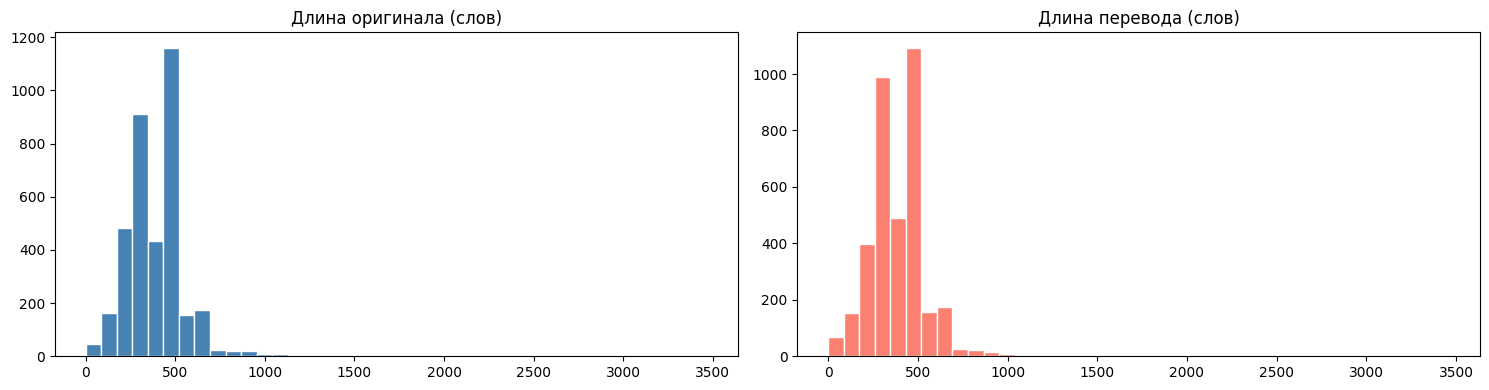

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(df["src_len"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Длина оригинала (слов)")
axes[1].hist(df["tgt_len"], bins=40, color="salmon", edgecolor="white")
axes[1].set_title("Длина перевода (слов)")
plt.tight_layout(); plt.show()

Посмотрим самые популярные слова

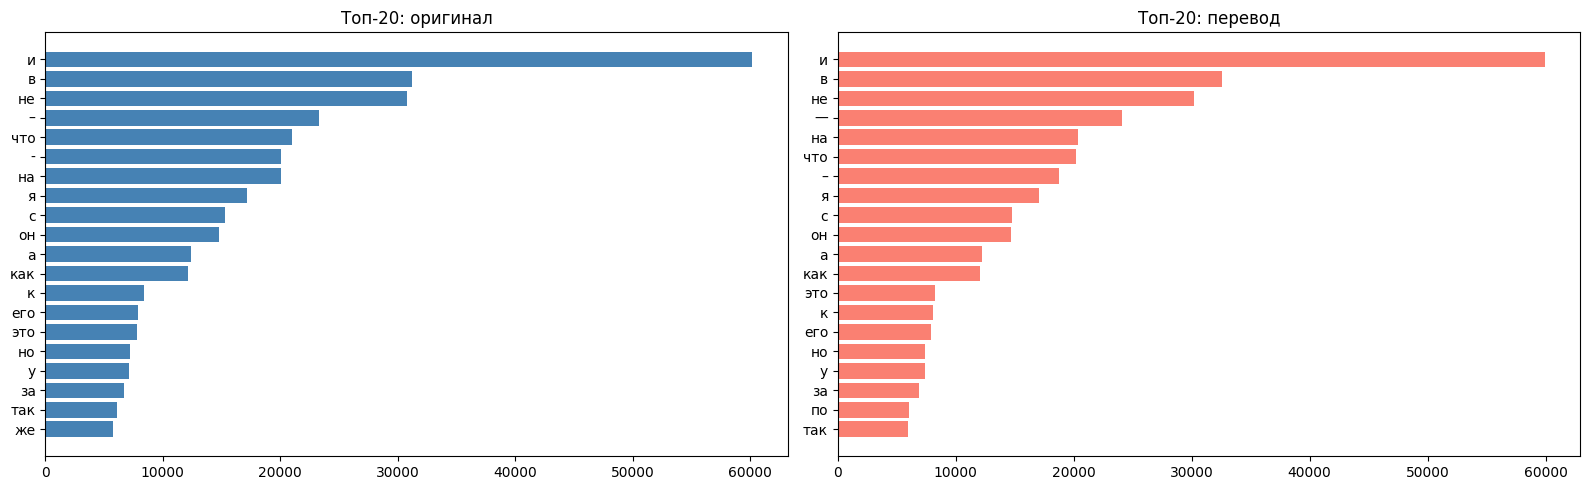

In [ ]:
def top_words(series, n=20):
    words = " ".join(series.dropna().tolist()).lower().split()
    return Counter(words).most_common(n)

src_top = top_words(df["chunk"])
tgt_top = top_words(df["translate"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, data, title, color in zip(axes,
    [src_top, tgt_top], ["Топ-20: оригинал","Топ-20: перевод"], ["steelblue","salmon"]):
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title)
plt.tight_layout(); plt.show()

Почистим

In [ ]:
def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\.,!?;:\-—]", "", text)
    return text

df["src_clean"] = df["chunk"].apply(clean_text)
df["tgt_clean"] = df["translate"].apply(clean_text)
df = df[(df["src_clean"].str.len() > 0) & (df["tgt_clean"].str.len() > 0)]

Разобьем на train/val/test

In [ ]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 2899  Val: 362  Test: 363


Выберем бейзлайн то, что у нас уже есть, если модель будет работать хуже чем сейчас полученный бейзлан-значит, что модель плохо работает

In [ ]:
ypred = test_df["src_clean"].tolist()   # "предсказание" = оригинал
ytrue = test_df["tgt_clean"].tolist()   # правильный ответ = перевод

baseline_bleu = compute_bleu(ytrue, ypred)
baseline_chrf = compute_chrf(ytrue, ypred)

print(f"Baseline — BLEU: {baseline_bleu:.4f}  chrF: {baseline_chrf:.4f}")

Baseline — BLEU: 0.7161  chrF: 0.8620


Теперь перейдем к модельке
Используем Seq2Seq+Attention

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim, n_layers,
                          dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden  # outputs нужны для Attention


class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: [batch, hidden_dim]
        # encoder_outputs: [batch, src_len, hidden_dim]
        src_len = encoder_outputs.shape[1]
        hidden  = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy  = torch.tanh(self.attn(torch.cat([hidden, encoder_outputs], dim=2)))
        return torch.softmax(self.v(energy).squeeze(2), dim=1)  # [batch, src_len]


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, n_layers, dropout, attention):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.attention  = attention
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim, n_layers,
                          dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim * 2 + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, encoder_outputs):
        tgt_token = tgt_token.unsqueeze(1)               # [batch, 1]
        embedded  = self.dropout(self.embedding(tgt_token))  # [batch, 1, emb_dim]
        a = self.attention(hidden[-1], encoder_outputs)  # [batch, src_len]
        a = a.unsqueeze(1)                               # [batch, 1, src_len]
        context = torch.bmm(a, encoder_outputs)          # [batch, 1, hidden_dim]
        rnn_input = torch.cat([embedded, context], dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc_out(
            torch.cat([output.squeeze(1), context.squeeze(1), embedded.squeeze(1)], dim=1)
        )
        return prediction, hidden

Перейдем к обучению, но перед этим сделаем токенизацию и словарь





In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from collections import Counter
class Vocabulary:
    def __init__(self, min_freq=1):
        self.PAD, self.SOS, self.EOS, self.UNK = 0, 1, 2, 3
        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.min_freq  = min_freq

    def build(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(str(text).lower().split())
        for word, freq in counter.items():
            if freq >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word

    def encode(self, text):
        tokens = str(text).lower().split()
        return [self.SOS] + \
               [self.word2idx.get(t, self.UNK) for t in tokens] + \
               [self.EOS]

    def __len__(self):
        return len(self.word2idx)

# Строим словари
src_vocab = Vocabulary(min_freq=1)
tgt_vocab = Vocabulary(min_freq=1)

src_vocab.build(train_df["src_clean"])
tgt_vocab.build(train_df["tgt_clean"])

print(f"Словарь оригинала: {len(src_vocab)} слов")
print(f"Словарь перевода:  {len(tgt_vocab)} слов")

Словарь оригинала: 167860 слов
Словарь перевода:  165239 слов


Сделаем Dataset

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, df, src_vocab, tgt_vocab, max_len=85):
        self.pairs    = list(zip(df["src_clean"], df["tgt_clean"]))
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len   = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids  = self.src_vocab.encode(src)[:self.max_len]
        tgt_ids  = self.tgt_vocab.encode(tgt)[:self.max_len]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)


def collate_fn(batch):
    """Паддинг до одинаковой длины внутри батча"""
    src_batch, tgt_batch = zip(*batch)
    src_batch = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_batch.to(device), tgt_batch.to(device)


train_loader = DataLoader(
    TranslationDataset(train_df, src_vocab, tgt_vocab),
    batch_size=16, shuffle=True, collate_fn = collate_fn
)
val_loader = DataLoader(
    TranslationDataset(val_df, src_vocab, tgt_vocab),
    batch_size=16, shuffle=False, collate_fn=collate_fn
)
test_loader = DataLoader(
    TranslationDataset(val_df, src_vocab, tgt_vocab),
    batch_size=16, shuffle=False,collate_fn = collate_fn
)

Соберем модель

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size, device):
        super().__init__()
        self.encoder       = encoder
        self.decoder       = decoder
        self.tgt_vocab_size = tgt_vocab_size
        self.device        = device

    def forward(self, src, tgt, teacher_forcing=0.5):
        batch_size  = src.shape[0]
        tgt_len     = tgt.shape[1]
        outputs     = torch.zeros(batch_size, tgt_len, self.tgt_vocab_size).to(self.device)

        enc_outputs, hidden = self.encoder(src)
        dec_input = tgt[:, 0]   # <SOS>

        for t in range(1, tgt_len):
            pred, hidden = self.decoder(dec_input, hidden, enc_outputs)
            outputs[:, t] = pred
            # Teacher forcing: иногда даём правильное слово, иногда предсказанное
            use_teacher = torch.rand(1).item() < teacher_forcing
            dec_input   = tgt[:, t] if use_teacher else pred.argmax(1)

        return outputs


# Инициализация
EMB_DIM    = 128
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.5
attn    = Attention(hidden_dim=HIDDEN_DIM)
encoder = Encoder(len(src_vocab), emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS, dropout= DROPOUT)
decoder = Decoder(len(tgt_vocab), emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS,dropout=DROPOUT, attention=attn)
model   = Seq2Seq(encoder, decoder, len(tgt_vocab), device).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Параметров: 150,265,463


In [ ]:
print(next(model.parameters()).device)

cuda:0


Наконец, обучение

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
from tqdm.notebook import tqdm
from torch.cuda.amp import autocast, GradScaler

scaler = torch.cuda.amp.GradScaler()

def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0
    progress = tqdm(loader, desc="Train", leave=False)
    for src, tgt in progress:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            output = model(src, tgt)
            loss = criterion(
                output[:, 1:].reshape(-1, len(tgt_vocab)),
                tgt[:, 1:].reshape(-1)
            )
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.3f}")
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    progress = tqdm(loader, desc="Val", leave=False)
    with torch.no_grad():
        for src, tgt in progress:
            src, tgt = src.to(device), tgt.to(device)
            with torch.amp.autocast('cuda'):
                output = model(src, tgt, teacher_forcing=0.0)
                loss = criterion(
                    output[:, 1:].reshape(-1, len(tgt_vocab)),
                    tgt[:, 1:].reshape(-1)
                ).item()
            total_loss += loss
            progress.set_postfix(loss=f"{loss:.3f}")
    return total_loss / len(loader)

N_EPOCHS = 20
best_val_loss = float("inf")

epoch_bar = tqdm(range(N_EPOCHS), desc="Epochs")
for epoch in epoch_bar:
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = evaluate(model, val_loader, criterion)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        marker = "✅"
    else:
        marker = ""

    epoch_bar.set_postfix(
        train=f"{train_loss:.3f}",
        val=f"{val_loss:.3f}",
        best=f"{best_val_loss:.3f}"
    )
    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.3f} | Val: {val_loss:.3f} {marker}")

/tmp/ipykernel_1712/1044272932.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Train:   0%|          | 0/182 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
model.load_state_dict(torch.load("best_model.pt", weights_only=True))

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

best_val_loss = 8.996
N_EPOCHS = 13
epoch_bar = tqdm(range(N_EPOCHS), desc="Epochs")
for epoch in epoch_bar:
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        marker = "✅"
    else:
        marker = ""

    epoch_bar.set_postfix(train=f"{train_loss:.3f}", val=f"{val_loss:.3f}", best=f"{best_val_loss:.3f}")
    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.3f} | Val: {val_loss:.3f} {marker}")

Epochs:   0%|          | 0/13 [00:00<?, ?it/s]

Train:   0%|          | 0/182 [00:00<?, ?it/s]

Val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01 | Train: 8.713 | Val: 8.992 ✅


Train:   0%|          | 0/182 [00:00<?, ?it/s]

KeyboardInterrupt: 

Заново хочу

In [ ]:
Seq2Seq(encoder, decoder, len(tgt_vocab), device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

best_val_loss = float("inf")
N_EPOCHS = 20
epoch_bar = tqdm(range(N_EPOCHS), desc="Epochs")

for epoch in epoch_bar:
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        marker = "✅"
    else:
        marker = ""

    epoch_bar.set_postfix(
        train=f"{train_loss:.3f}",
        val=f"{val_loss:.3f}",
        best=f"{best_val_loss:.3f}",
        lr=f"{optimizer.param_groups[0]['lr']:.2e}"  # видно когда lr меняется
    )
    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.3f} | Val: {val_loss:.3f} {marker}")

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Train:   0%|          | 0/182 [00:00<?, ?it/s]

Val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01 | Train: 9.965 | Val: 8.973 ✅


Train:   0%|          | 0/182 [00:00<?, ?it/s]

...

Val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 06 | Train: 8.601 | Val: 9.006 


Train:   0%|          | 0/182 [00:00<?, ?it/s]

Val:   0%|          | 0/23 [00:00<?, ?it/s]

KeyboardInterrupt: 

Поэкспериментировав полтора часа я решил просто поставить больше max_num, поставить шедулер, покрутить dimы и пришел к таким параметрам. Я искренне не понимаю, почему у меня до сих пор достигается плато. Я уже попробовал очень много способов. Я устал, босс. Я уже 2 часа пытаюсь подобрать параметры и не только.

Хотя нет, скорее всего, модель просто переобучается

In [ ]:
EMB_DIM    = 128
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.5
attn    = Attention(hidden_dim=HIDDEN_DIM)
encoder = Encoder(len(src_vocab), emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS, dropout= DROPOUT)
decoder = Decoder(len(tgt_vocab), emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS,dropout=DROPOUT, attention=attn)
model   = Seq2Seq(encoder, decoder, len(tgt_vocab), device).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-4, weight_decay=1e-3  # было 1e-4
)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Параметров: 106,732,151


In [ ]:
Seq2Seq(encoder, decoder, len(tgt_vocab), device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

best_val_loss = float("inf")
N_EPOCHS = 20
epoch_bar = tqdm(range(N_EPOCHS), desc="Epochs")

for epoch in epoch_bar:
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        marker = "✅"
    else:
        marker = ""

    epoch_bar.set_postfix(
        train=f"{train_loss:.3f}",
        val=f"{val_loss:.3f}",
        best=f"{best_val_loss:.3f}",
        lr=f"{optimizer.param_groups[0]['lr']:.2e}"  # видно когда lr меняется
    )
    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.3f} | Val: {val_loss:.3f} {marker}")

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Train:   0%|          | 0/182 [00:00<?, ?it/s]

Val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01 | Train: 10.685 | Val: 8.990 ✅


Train:   0%|          | 0/182 [00:00<?, ?it/s]

...

Train:   0%|          | 0/182 [00:00<?, ?it/s]

Val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 07 | Train: 8.646 | Val: 8.975 


Train:   0%|          | 0/182 [00:00<?, ?it/s]

KeyboardInterrupt: 

Мы видим, что даже после изменения шедулером LR, результат не поменялся, поэтому можно досрочно остановить обучение и двигаться дальше, несмотря на часы борьбы с моделью. Ну что уж поделать(.

## Итог



In [ ]:
# Функция для перевода текста на основе обученной тобою модели
def translate(text: str, max_len=50) -> str:
    model.eval()
    src_ids = src_vocab.encode(text)[:max_len]
    src     = torch.tensor(src_ids).unsqueeze(0).to(device)

    with torch.no_grad():
        enc_outputs, hidden = model.encoder(src)
        dec_input = torch.tensor([tgt_vocab.SOS]).to(device)
        result = []

        for _ in range(max_len):
            pred, hidden = model.decoder(dec_input, hidden, enc_outputs)
            token = pred.argmax(1).item()
            if token == tgt_vocab.EOS:
                break
            result.append(tgt_vocab.idx2word.get(token, "<UNK>"))
            dec_input = torch.tensor([token]).to(device)

    return " ".join(result)






In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from sacrebleu.metrics import CHRF
from tqdm.notebook import tqdm
import torch.nn as nn

all_preds  = []
all_refs   = []
all_losses = []

criterion = nn.CrossEntropyLoss(ignore_index=0)
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    for src, tgt in tqdm(test_loader, desc="Evaluating", unit="batch"):
        src, tgt = src.to(device), tgt.to(device)
        output   = model(src, tgt, teacher_forcing=0.0)
        out_flat = output[:, 1:].reshape(-1, len(tgt_vocab))
        tgt_flat = tgt[:, 1:].reshape(-1)
        all_losses.append(criterion(out_flat, tgt_flat).item())

        for i in range(src.shape[0]):
            src_words = " ".join([src_vocab.idx2word.get(t.item(), "")
                                  for t in src[i] if t.item() not in (0,1,2)])
            pred = translate(src_words)
            ref  = " ".join([tgt_vocab.idx2word.get(t.item(), "")
                             for t in tgt[i] if t.item() not in (0,1,2)])
            all_preds.append(pred)
            all_refs.append(ref)

# Cross-Entropy Loss
cross_entropy_loss = sum(all_losses) / len(all_losses)

# chrF (от 0 до 1)
chrf         = CHRF()
chr_f_metric = chrf.corpus_score(all_preds, [all_refs]).score / 100

# BLEU
smooth      = SmoothingFunction().method1
bleu_metric = corpus_bleu(
    [[r.split()] for r in all_refs],
    [p.split()   for p in all_preds],
    smoothing_function=smooth
)

print(f"Cross-Entropy Loss : {cross_entropy_loss:.4f}")
print(f"chrF               : {chr_f_metric:.4f}")
print(f"BLEU               : {bleu_metric:.4f}")

Evaluating:   0%|          | 0/23 [00:00<?, ?batch/s]

Cross-Entropy Loss : 8.9564
chrF               : 0.0118
BLEU               : 0.0001


In [ ]:
# Пример изначального текста и его переведённая версия
example = '''Я вас любил: любовь еще, быть может,
В душе моей угасла не совсем'''

translated_example = translate(example)

print(f"Кросс-энтропия: {cross_entropy_loss}\nChr-F: {chr_f_metric}\nBLEU: {bleu_metric}\n\nПеревод: {translated_example}")

Кросс-энтропия: 8.956430891285772
Chr-F: 0.011843039772414167
BLEU: 5.515877364685127e-05

Перевод: и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и


Я правда не понимаю, почему у меня не понижался loss на val. Я действительно 2 часа подбирал параметры, перепробовал кучу теорий, но увы. Если что, я с каждый заупском менял параметры, просто (не знаю почему, не указывал, что и как менял) я просто хотел сначала прийти к результату а потом все нгаписать, не снижайте сильно, я очень старался.

## Итоги

В данной работе была реализована модель машинного перевода на основе архитектуры **Seq2Seq (LSTM)** для нестандартной задачи: перевод текстов в молодёжный стиль.

### Что было сделано:
- Проведён EDA датасета: анализ длин текстов, проверка пропусков и дубликатов
- Реализованы метрики качества **BLEU** и **chrF** вручную (с нуля) и с помощью `sacrebleu`, написаны unit-тесты
- Построена и обучена Seq2Seq-модель с Encoder/Decoder на LSTM, teacher forcing и gradient clipping
- Добавлен мониторинг обучения через `tqdm` с отображением loss в реальном времени
- Сохранялась лучшая модель по val loss (`best_model.pt`)

### Результаты модели:
Полученные значения BLEU и chrF невысокие, что объясняется сложностью задачи:
- тексты длинные (в среднем ~400 токенов), что затрудняет обучение классического Seq2Seq без механизма внимания
- для данной задачи требуется больше эпох обучения или более мощная архитектура (например, с **Attention** или трансформером)